# Stage 1: Data Loading and Initial Exploration

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load Tesla sales data
sales_df = pd.read_csv('data/tesla_sales.csv')
print("Tesla Sales Data Structure:")
print(sales_df.head())
print("\nSales Data Info:")
print(sales_df.info())
print("\nSales Data Description:")
print(sales_df.describe())

# Load news data
news_df = pd.read_csv('data/news.csv')
print("\nNews Data Structure:")
print(news_df.head())
print("\nNews Data Info:")
print(news_df.info())
print("\nNews Data Description:")
print(news_df.describe())

## Stage 2: Data Type Conversion and Basic Visualization

In [ ]:
# Convert date columns to datetime with proper format handling
if 'date' in sales_df.columns:
    sales_df['date'] = pd.to_datetime(sales_df['date'])

if 'date' in news_df.columns:
    # First, let's see the format of the dates
    print("Sample of news dates:", news_df['date'].head())
    
    # Convert news dates using format='mixed' to handle different date formats
    news_df['date'] = pd.to_datetime(news_df['date'], format='mixed', dayfirst=True)

# Basic visualization of sales data
plt.figure(figsize=(12, 6))
if 'date' in sales_df.columns and 'sales' in sales_df.columns:
    plt.plot(sales_df['date'], sales_df['sales'])
    plt.title('Tesla Sales Over Time')
    plt.xlabel('Date')
    plt.ylabel('Number of Vehicles Sold')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Basic visualization of news data frequency
plt.figure(figsize=(12, 6))
if 'date' in news_df.columns:
    # Group by month to reduce noise in the visualization
    news_df['month'] = news_df['date'].dt.to_period('M')
    monthly_counts = news_df.groupby('month').size()
    monthly_counts.plot()
    plt.title('News Article Frequency Over Time (Monthly)')
    plt.xlabel('Date')
    plt.ylabel('Number of Articles')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Print date ranges for both datasets
print("\nDate Ranges:")
print("Sales data:", sales_df['date'].min(), "to", sales_df['date'].max())
print("News data:", news_df['date'].min(), "to", news_df['date'].max())

## Stage 3: Data Cleaning and Feature Engineering

In [ ]:
# Ensure sales_df date is in datetime format
sales_df['date'] = pd.to_datetime(sales_df['date'])

# Create a new DataFrame with the required columns
analysis_df = pd.DataFrame()

# Extract year and month (previous month)
analysis_df['year'] = sales_df['date'].dt.year
analysis_df['month'] = sales_df['date'].dt.month
analysis_df['sales'] = sales_df['sales']

# Display the processed data
print("\nProcessed Data Structure:")
print(analysis_df.head())
print("\nProcessed Data Info:")
print(analysis_df.info())
print("\nProcessed Data Description:")
print(analysis_df.describe())

# Create a figure with a larger size
plt.figure(figsize=(15, 8))

# Create a line plot of sales over time
plt.plot(analysis_df.index, analysis_df['sales'], 'b-', linewidth=2, label='Monthly Sales')

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Set title and labels
plt.title('Tesla Monthly Sales Over Time', fontsize=14, pad=20)
plt.xlabel('Time', fontsize=12)
plt.ylabel('Number of Vehicles Sold', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add a legend
plt.legend(fontsize=10)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Show the plot
plt.show()

# Optional: Create a box plot to show sales distribution by year
plt.figure(figsize=(12, 6))

# Group sales by year and create box plot
sns.boxplot(x='year', y='sales', data=analysis_df)

# Set title and labels
plt.title('Tesla Sales Distribution by Year', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Vehicles Sold', fontsize=12)

# Add grid for better readability
plt.grid(True, linestyle='--', alpha=0.7)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Optional: Create a heatmap of sales by month and year
# Pivot the data for heatmap
heatmap_data = analysis_df.pivot(index='year', columns='month', values='sales')

# Create the heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt='.0f', linewidths=.5)

# Set title and labels
plt.title('Tesla Sales Heatmap by Month and Year', fontsize=14, pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Year', fontsize=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Stage 4: News Content Cleaning and Preprocessing

In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download all required NLTK data
try:
    nltk.download('punkt')
    nltk.download('stopwords')
    nltk.download('wordnet')
    nltk.download('omw-1.4')
    nltk.download('punkt_tab')
except Exception as e:
    print(f"Error downloading NLTK data: {e}")

def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Remove escape characters and special symbols
    text = re.sub(r'\\[nrt]', ' ', text)  # Remove \n, \r, \t
    text = re.sub(r'\\[a-zA-Z]', ' ', text)  # Remove other escape sequences
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text.lower()

def preprocess_news_content(df):
    try:
        # Create a copy to avoid modifying the original
        df = df.copy()
        
        # Clean title and content
        df['cleaned_title'] = df['title'].apply(clean_text)
        df['cleaned_content'] = df['content'].apply(clean_text)
        
        # Combine title and content
        df['combined_text'] = df['cleaned_title'] + ' ' + df['cleaned_content']
        
        # Tokenize the text
        df['tokens'] = df['combined_text'].apply(word_tokenize)
        
        # Remove stopwords
        stop_words = set(stopwords.words('english'))
        df['filtered_tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])
        
        # Lemmatize words
        lemmatizer = WordNetLemmatizer()
        df['lemmatized_tokens'] = df['filtered_tokens'].apply(
            lambda x: [lemmatizer.lemmatize(word) for word in x]
        )
        
        # Join tokens back into text
        df['processed_text'] = df['lemmatized_tokens'].apply(lambda x: ' '.join(x))
        
        # Count words in processed text
        df['word_count'] = df['processed_text'].apply(lambda x: len(x.split()))
        
        return df
    except Exception as e:
        print(f"Error in preprocessing: {e}")
        return None

# Preprocess the news data
news_df_processed = preprocess_news_content(news_df)

if news_df_processed is not None:
    # Display sample of processed text
    print("\nSample of Original vs Processed Text:")
    sample = news_df_processed[['title', 'processed_text']].head()
    print(sample)

    # Display basic statistics
    print("\nText Processing Statistics:")
    print(f"Average word count per article: {news_df_processed['word_count'].mean():.2f}")
    print(f"Total unique words: {len(set(' '.join(news_df_processed['processed_text']).split()))}")

    # Create a word frequency distribution
    from collections import Counter
    all_words = ' '.join(news_df_processed['processed_text']).split()
    word_freq = Counter(all_words)

    # Display top 20 most common words
    print("\nTop 20 Most Common Words:")
    for word, count in word_freq.most_common(20):
        print(f"{word}: {count}")

    # Visualize word frequency
    plt.figure(figsize=(12, 6))
    words, counts = zip(*word_freq.most_common(20))
    plt.bar(words, counts)
    plt.title('Top 20 Most Common Words in News Articles')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Preprocessing failed. Please check the error messages above.")

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

def create_word_cloud(text, title="Word Cloud"):
    """Create and display a word cloud from text"""
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        max_words=100,
        contour_width=3,
        contour_color='steelblue'
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_word_frequency_distribution(word_freq, top_n=20):
    """Plot word frequency distribution"""
    plt.figure(figsize=(12, 6))
    words, counts = zip(*word_freq.most_common(top_n))
    sns.barplot(x=list(words), y=list(counts))
    plt.title(f'Top {top_n} Most Frequent Words')
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def plot_word_length_distribution(text):
    """Plot distribution of word lengths"""
    words = text.split()
    word_lengths = [len(word) for word in words]
    
    plt.figure(figsize=(10, 6))
    sns.histplot(word_lengths, bins=30)
    plt.title('Distribution of Word Lengths')
    plt.xlabel('Word Length')
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

def plot_monthly_word_count(news_df):
    """Plot monthly word count trends"""
    # Convert date to datetime and extract month
    news_df['date'] = pd.to_datetime(news_df['date'])
    news_df['month'] = news_df['date'].dt.to_period('M')
    
    # Group by month and calculate average word count
    monthly_stats = news_df.groupby('month')['word_count'].agg(['mean', 'count']).reset_index()
    monthly_stats['month'] = monthly_stats['month'].astype(str)
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
    
    # Plot average word count
    sns.lineplot(data=monthly_stats, x='month', y='mean', ax=ax1)
    ax1.set_title('Average Word Count per Article by Month')
    ax1.set_xlabel('Month')
    ax1.set_ylabel('Average Word Count')
    ax1.tick_params(axis='x', rotation=45)
    
    # Plot number of articles
    sns.barplot(data=monthly_stats, x='month', y='count', ax=ax2)
    ax2.set_title('Number of Articles by Month')
    ax2.set_xlabel('Month')
    ax2.set_ylabel('Number of Articles')
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Create word cloud for all processed text
all_text = ' '.join(news_df_processed['processed_text'])
create_word_cloud(all_text, "Word Cloud of All Articles")

# Create word cloud for titles only
title_text = ' '.join(news_df_processed['cleaned_title'])
create_word_cloud(title_text, "Word Cloud of Article Titles")

# Plot word frequency distribution
word_freq = Counter(all_text.split())
plot_word_frequency_distribution(word_freq)

# Plot word length distribution
plot_word_length_distribution(all_text)

# Plot monthly word count trends
plot_monthly_word_count(news_df_processed)

# Additional analysis: Most common bigrams
from nltk import bigrams
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

# Create bigram finder
bigram_finder = BigramCollocationFinder.from_words(all_text.split())
bigram_finder.apply_freq_filter(3)  # Only show bigrams that appear at least 3 times

# Get top 20 bigrams
top_bigrams = bigram_finder.nbest(BigramAssocMeasures.raw_freq, 20)

# Plot bigram frequency
plt.figure(figsize=(12, 6))
bigram_text = [' '.join(bg) for bg in top_bigrams]
bigram_freq = [bigram_finder.ngram_fd[bg] for bg in top_bigrams]
sns.barplot(x=bigram_text, y=bigram_freq)
plt.title('Top 20 Most Common Bigrams')
plt.xlabel('Bigrams')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print statistics
print("\nText Analysis Statistics:")
print(f"Total number of articles: {len(news_df_processed)}")
print(f"Total number of words: {len(all_text.split())}")
print(f"Average words per article: {np.mean(news_df_processed['word_count']):.2f}")
print(f"Median words per article: {np.median(news_df_processed['word_count']):.2f}")
print(f"Standard deviation of word count: {np.std(news_df_processed['word_count']):.2f}")

## Stage 5: sentiment analysis

### With VADER (Valence Aware Dictionary and sEntiment Reasoner) from NLTK

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Download VADER lexicon
nltk.download('vader_lexicon')

def analyze_sentiment(text):
    sia = SentimentIntensityAnalyzer()
    return sia.polarity_scores(text)

def preprocess_for_sentiment(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])
    df['sentiment_scores'] = df['processed_text'].apply(analyze_sentiment)
    df['negative'] = df['sentiment_scores'].apply(lambda x: x['neg'])
    df['neutral']  = df['sentiment_scores'].apply(lambda x: x['neu'])
    df['positive'] = df['sentiment_scores'].apply(lambda x: x['pos'])
    df['compound'] = df['sentiment_scores'].apply(lambda x: x['compound'])
    df['sentiment'] = df['compound'].apply(lambda x: 
        'positive' if x >= 0.05 
        else 'negative' if x <= -0.05 
        else 'neutral'
    )
    return df

# Run VADER sentiment analysis
news_df_sentiment = preprocess_for_sentiment(news_df_processed)

# Save with method-specific filename
from datetime import datetime
vader_filename = f"results/vader_sentiment_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
news_df_sentiment.to_csv(vader_filename, index=False)

# Display sample of sentiment analysis
print("\nSample of Sentiment Analysis Results:")
print(news_df_sentiment[['date', 'title', 'sentiment', 'compound']].head())

# Plot sentiment distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=news_df_sentiment, x='sentiment', order=['positive', 'neutral', 'negative'])
plt.title('Distribution of Article Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Articles')
plt.show()

# Plot sentiment scores over time
plt.figure(figsize=(12, 6))
news_df_sentiment.set_index('date')['compound'].plot()
plt.title('Sentiment Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Compound Sentiment Score')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)
plt.show()

# Monthly sentiment analysis
def plot_monthly_sentiment(df):
    """Plot monthly sentiment trends"""
    # Group by month
    monthly_sentiment = df.groupby(df['date'].dt.to_period('M')).agg({
        'compound': 'mean',
        'positive': 'mean',
        'negative': 'mean',
        'neutral': 'mean'
    }).reset_index()
    
    monthly_sentiment['date'] = monthly_sentiment['date'].astype(str)
    
    # Plot monthly sentiment trends
    plt.figure(figsize=(12, 8))
    plt.plot(monthly_sentiment['date'], monthly_sentiment['compound'], 
             label='Compound', marker='o')
    plt.plot(monthly_sentiment['date'], monthly_sentiment['positive'], 
             label='Positive', marker='o')
    plt.plot(monthly_sentiment['date'], monthly_sentiment['negative'], 
             label='Negative', marker='o')
    plt.plot(monthly_sentiment['date'], monthly_sentiment['neutral'], 
             label='Neutral', marker='o')
    
    plt.title('Monthly Sentiment Trends')
    plt.xlabel('Month')
    plt.ylabel('Sentiment Score')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot monthly sentiment trends
plot_monthly_sentiment(news_df_sentiment)

# Sentiment statistics
print("\nSentiment Analysis Statistics:")
print(f"Average compound score: {news_df_sentiment['compound'].mean():.3f}")
print(f"Median compound score: {news_df_sentiment['compound'].median():.3f}")
print(f"Standard deviation of compound scores: {news_df_sentiment['compound'].std():.3f}")
print("\nSentiment Distribution:")
print(news_df_sentiment['sentiment'].value_counts(normalize=True).round(3))

# Correlation between sentiment and word count
plt.figure(figsize=(10, 6))
sns.scatterplot(data=news_df_sentiment, x='word_count', y='compound')
plt.title('Relationship between Article Length and Sentiment')
plt.xlabel('Word Count')
plt.ylabel('Compound Sentiment Score')
plt.grid(True)
plt.show()

# Print correlation coefficient
correlation = news_df_sentiment['word_count'].corr(news_df_sentiment['compound'])
print(f"\nCorrelation between word count and sentiment: {correlation:.3f}")

### Transformers library for sentiment analysis

In [ ]:
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

# Initialize the tokenizer and model separately for better control
model_name = "mrm8488/distilroberta-finetuned-financial-news-sentiment-analysis"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

# Move model to appropriate device
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

def chunk_text(text, max_length=512):
    """Split text into chunks that fit within the model's maximum length"""
    words = text.split()
    chunks = []
    current_chunk = []
    current_length = 0
    
    for word in words:
        # Add 1 for space
        word_length = len(tokenizer.encode(word)) + 1
        if current_length + word_length > max_length:
            chunks.append(' '.join(current_chunk))
            current_chunk = [word]
            current_length = word_length
        else:
            current_chunk.append(word)
            current_length += word_length
    
    if current_chunk:
        chunks.append(' '.join(current_chunk))
    
    return chunks

def analyze_sentiment_transformers(text, max_length=512):
    """Analyze sentiment using Transformers model with proper text chunking"""
    try:
        # Split text into chunks if necessary
        chunks = chunk_text(text, max_length)
        
        # Initialize sentiment scores
        label_scores = {'positive': 0, 'negative': 0, 'neutral': 0}
        
        # Process each chunk
        for chunk in chunks:
            # Tokenize and truncate if necessary
            inputs = tokenizer(chunk, return_tensors="pt", truncation=True, max_length=max_length)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            
            # Get model predictions
            with torch.no_grad():
                outputs = model(**inputs)
                scores = torch.softmax(outputs.logits, dim=1)[0]
                
                # Map model outputs to sentiment labels
                label_scores['positive'] += scores[2].item()  # Assuming index 2 is positive
                label_scores['negative'] += scores[0].item()  # Assuming index 0 is negative
                label_scores['neutral'] += scores[1].item()   # Assuming index 1 is neutral
        
        # Normalize scores
        total = sum(label_scores.values())
        if total > 0:
            return {k: v/total for k, v in label_scores.items()}
        else:
            return {'positive': 0, 'negative': 0, 'neutral': 0}
            
    except Exception as e:
        print(f"Error analyzing sentiment: {e}")
        return {'positive': 0, 'negative': 0, 'neutral': 0}

def preprocess_for_transformers_sentiment(df):
    """Prepare data for sentiment analysis using Transformers"""
    # Create a copy to avoid modifying original
    df = df.copy()
    
    # Convert date to datetime
    df['date'] = pd.to_datetime(df['date'])
    
    # Analyze sentiment for each article
    print("Analyzing sentiment for articles...")
    df['sentiment_scores'] = df['processed_text'].apply(analyze_sentiment_transformers)
    
    # Extract individual sentiment scores
    df['positive'] = df['sentiment_scores'].apply(lambda x: x.get('positive', 0))
    df['negative'] = df['sentiment_scores'].apply(lambda x: x.get('negative', 0))
    df['neutral'] = df['sentiment_scores'].apply(lambda x: x.get('neutral', 0))
    
    # Create compound score (positive - negative)
    df['compound'] = df['positive'] - df['negative']
    
    # Create sentiment label based on highest score
    df['sentiment'] = df[['positive', 'negative', 'neutral']].idxmax(axis=1)
    
    return df

# Perform sentiment analysis
print("Starting sentiment analysis with Transformers...")
news_df_transformers = preprocess_for_transformers_sentiment(news_df_processed)

# Display sample of sentiment analysis
print("\nSample of Transformers Sentiment Analysis Results:")
print(news_df_transformers[['date', 'title', 'sentiment', 'compound']].head())

# Plot sentiment distribution
plt.figure(figsize=(10, 6))
sns.countplot(data=news_df_transformers, x='sentiment', 
              order=['positive', 'neutral', 'negative'])
plt.title('Distribution of Article Sentiments (Transformers)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Articles')
plt.show()

# Plot sentiment scores over time
plt.figure(figsize=(12, 6))
news_df_transformers.set_index('date')['compound'].plot()
plt.title('Sentiment Trend Over Time (Transformers)')
plt.xlabel('Date')
plt.ylabel('Compound Sentiment Score')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)
plt.show()

# Monthly sentiment analysis
def plot_monthly_sentiment_transformers(df):
    """Plot monthly sentiment trends using Transformers results"""
    # Group by month
    monthly_sentiment = df.groupby(df['date'].dt.to_period('M')).agg({
        'compound': 'mean',
        'positive': 'mean',
        'negative': 'mean',
        'neutral': 'mean'
    }).reset_index()
    
    monthly_sentiment['date'] = monthly_sentiment['date'].astype(str)
    
    # Plot monthly sentiment trends
    plt.figure(figsize=(12, 8))
    plt.plot(monthly_sentiment['date'], monthly_sentiment['compound'], 
             label='Compound', marker='o')
    plt.plot(monthly_sentiment['date'], monthly_sentiment['positive'], 
             label='Positive', marker='o')
    plt.plot(monthly_sentiment['date'], monthly_sentiment['negative'], 
             label='Negative', marker='o')
    plt.plot(monthly_sentiment['date'], monthly_sentiment['neutral'], 
             label='Neutral', marker='o')
    
    plt.title('Monthly Sentiment Trends (Transformers)')
    plt.xlabel('Month')
    plt.ylabel('Sentiment Score')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot monthly sentiment trends
plot_monthly_sentiment_transformers(news_df_transformers)

# Sentiment statistics
print("\nTransformers Sentiment Analysis Statistics:")
print(f"Average positive score: {news_df_transformers['positive'].mean():.3f}")
print(f"Average negative score: {news_df_transformers['negative'].mean():.3f}")
print(f"Average neutral score: {news_df_transformers['neutral'].mean():.3f}")
print(f"Average compound score: {news_df_transformers['compound'].mean():.3f}")
print("\nSentiment Distribution:")
print(news_df_transformers['sentiment'].value_counts(normalize=True).round(3))

# Correlation between sentiment and word count
plt.figure(figsize=(10, 6))
sns.scatterplot(data=news_df_transformers, x='word_count', y='compound')
plt.title('Relationship between Article Length and Sentiment (Transformers)')
plt.xlabel('Word Count')
plt.ylabel('Compound Sentiment Score')
plt.grid(True)
plt.show()

# Print correlation coefficient
correlation = news_df_transformers['word_count'].corr(news_df_transformers['compound'])
print(f"\nCorrelation between word count and sentiment: {correlation:.3f}")


transformers_filename = f"results/transformers_sentiment_analysis_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
news_df_transformers.to_csv(transformers_filename, index=False)

#### Save the results to a CSV file

In [ ]:
import os
from datetime import datetime

def save_sentiment_analysis_results(df, filename=None):
    """
    Save sentiment analysis results to a CSV file
    
    Args:
        df (pd.DataFrame): DataFrame containing sentiment analysis results
        filename (str, optional): Custom filename. If None, generates timestamp-based name
    """
    # Create results directory if it doesn't exist
    if not os.path.exists('results'):
        os.makedirs('results')
    
    # Generate filename if not provided
    if filename is None:
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'results/sentiment_analysis_{timestamp}.csv'
    else:
        # Ensure filename has .csv extension
        if not filename.endswith('.csv'):
            filename += '.csv'
        # Ensure filename is in results directory
        if not filename.startswith('results/'):
            filename = f'results/{filename}'
    
    # Select columns to save
    columns_to_save = [
        'date',
        'title',
        'processed_text',
        'word_count',
        'positive',
        'negative',
        'neutral',
        'compound',
        'sentiment'
    ]
    
    # Create DataFrame with selected columns
    results_df = df[columns_to_save].copy()
    
    # Save to CSV
    results_df.to_csv(filename, index=False)
    print(f"Results saved to {filename}")
    
    # Also save summary statistics
    summary_filename = filename.replace('.csv', '_summary.txt')
    with open(summary_filename, 'w') as f:
        f.write("Sentiment Analysis Summary\n")
        f.write("=" * 50 + "\n\n")
        
        f.write("Overall Statistics:\n")
        f.write(f"Total articles analyzed: {len(df)}\n")
        f.write(f"Average word count: {df['word_count'].mean():.2f}\n")
        f.write(f"Median word count: {df['word_count'].median():.2f}\n\n")
        
        f.write("Sentiment Distribution:\n")
        sentiment_dist = df['sentiment'].value_counts(normalize=True).round(3)
        for sentiment, proportion in sentiment_dist.items():
            f.write(f"{sentiment}: {proportion:.3f}\n")
        f.write("\n")
        
        f.write("Average Sentiment Scores:\n")
        f.write(f"Positive: {df['positive'].mean():.3f}\n")
        f.write(f"Negative: {df['negative'].mean():.3f}\n")
        f.write(f"Neutral: {df['neutral'].mean():.3f}\n")
        f.write(f"Compound: {df['compound'].mean():.3f}\n\n")
        
        f.write("Monthly Statistics:\n")
        monthly_stats = df.groupby(df['date'].dt.to_period('M')).agg({
            'compound': 'mean',
            'positive': 'mean',
            'negative': 'mean',
            'neutral': 'mean'
        }).round(3)
        f.write(monthly_stats.to_string())
    
    print(f"Summary statistics saved to {summary_filename}")
    
    return filename, summary_filename

# Save the results
results_file, summary_file = save_sentiment_analysis_results(news_df_transformers)

# Print confirmation
print("\nFiles created:")
print(f"1. Detailed results: {results_file}")
print(f"2. Summary statistics: {summary_file}")

# Display first few lines of the saved file
print("\nFirst few lines of saved results:")
print(pd.read_csv(results_file).head())

#### Load Data if they already exist

In [ ]:
import os
import pandas as pd
from datetime import datetime
import glob

def load_sentiment_analysis_results(results_dir='results'):
    """
    Load the most recent sentiment analysis results from the results directory
    
    Args:
        results_dir (str): Directory containing the results files
        
    Returns:
        tuple: (DataFrame with results, summary statistics dict, timestamp)
    """
    try:
        # Check if results directory exists
        if not os.path.exists(results_dir):
            print(f"Results directory '{results_dir}' not found.")
            return None, None, None
        
        # Find all sentiment analysis CSV files
        csv_files = glob.glob(os.path.join(results_dir, 'sentiment_analysis_*.csv'))
        if not csv_files:
            print("No sentiment analysis files found.")
            return None, None, None
        
        # Get the most recent file
        latest_file = max(csv_files, key=os.path.getctime)
        timestamp = os.path.basename(latest_file).split('_')[2].split('.')[0]
        
        # Load the CSV file
        print(f"Loading results from {latest_file}")
        df = pd.read_csv(latest_file)
        
        # Convert date column to datetime
        df['date'] = pd.to_datetime(df['date'])
        
        # Load summary statistics
        summary_file = latest_file.replace('.csv', '_summary.txt')
        summary_stats = {}
        
        if os.path.exists(summary_file):
            print(f"Loading summary statistics from {summary_file}")
            with open(summary_file, 'r') as f:
                current_section = None
                for line in f:
                    line = line.strip()
                    if not line:
                        continue
                    
                    if line.endswith(':'):
                        current_section = line[:-1]
                        summary_stats[current_section] = {}
                    elif current_section and ':' in line:
                        key, value = line.split(':', 1)
                        summary_stats[current_section][key.strip()] = value.strip()
        
        # Validate loaded data
        required_columns = [
            'date', 'title', 'processed_text', 'word_count',
            'positive', 'negative', 'neutral', 'compound', 'sentiment'
        ]
        
        missing_columns = [col for col in required_columns if col not in df.columns]
        if missing_columns:
            print(f"Warning: Missing columns in loaded data: {missing_columns}")
        
        # Print basic information about loaded data
        print("\nLoaded Data Summary:")
        print(f"Number of articles: {len(df)}")
        print(f"Date range: {df['date'].min().strftime('%Y-%m-%d')} to {df['date'].max().strftime('%Y-%m-%d')}")
        print(f"Sentiment distribution:")
        print(df['sentiment'].value_counts(normalize=True).round(3))
        
        return df, summary_stats, timestamp
    
    except Exception as e:
        print(f"Error loading sentiment analysis results: {e}")
        return None, None, None

# Load the data
df, summary_stats, timestamp = load_sentiment_analysis_results()

if df is not None:
    # Display sample of loaded data
    print("\nSample of loaded data:")
    print(df.head())
    
    # Display summary statistics if available
    if summary_stats:
        print("\nSummary Statistics:")
        for section, stats in summary_stats.items():
            print(f"\n{section}:")
            for key, value in stats.items():
                print(f"  {key}: {value}")
    
    # Create a function to get monthly sentiment trends
    def get_monthly_sentiment_trends(df):
        monthly_trends = df.groupby(df['date'].dt.to_period('M')).agg({
            'compound': 'mean',
            'positive': 'mean',
            'negative': 'mean',
            'neutral': 'mean'
        }).round(3)
        return monthly_trends
    
    # Get and display monthly trends
    monthly_trends = get_monthly_sentiment_trends(df)
    print("\nMonthly Sentiment Trends:")
    print(monthly_trends)
    
    # Plot monthly trends
    plt.figure(figsize=(12, 6))
    monthly_trends['compound'].plot(marker='o')
    plt.title('Monthly Compound Sentiment Trend')
    plt.xlabel('Month')
    plt.ylabel('Compound Sentiment Score')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("No data was loaded. Please ensure sentiment analysis has been run and results are saved.")

### Comparison of sentiment analysis methods

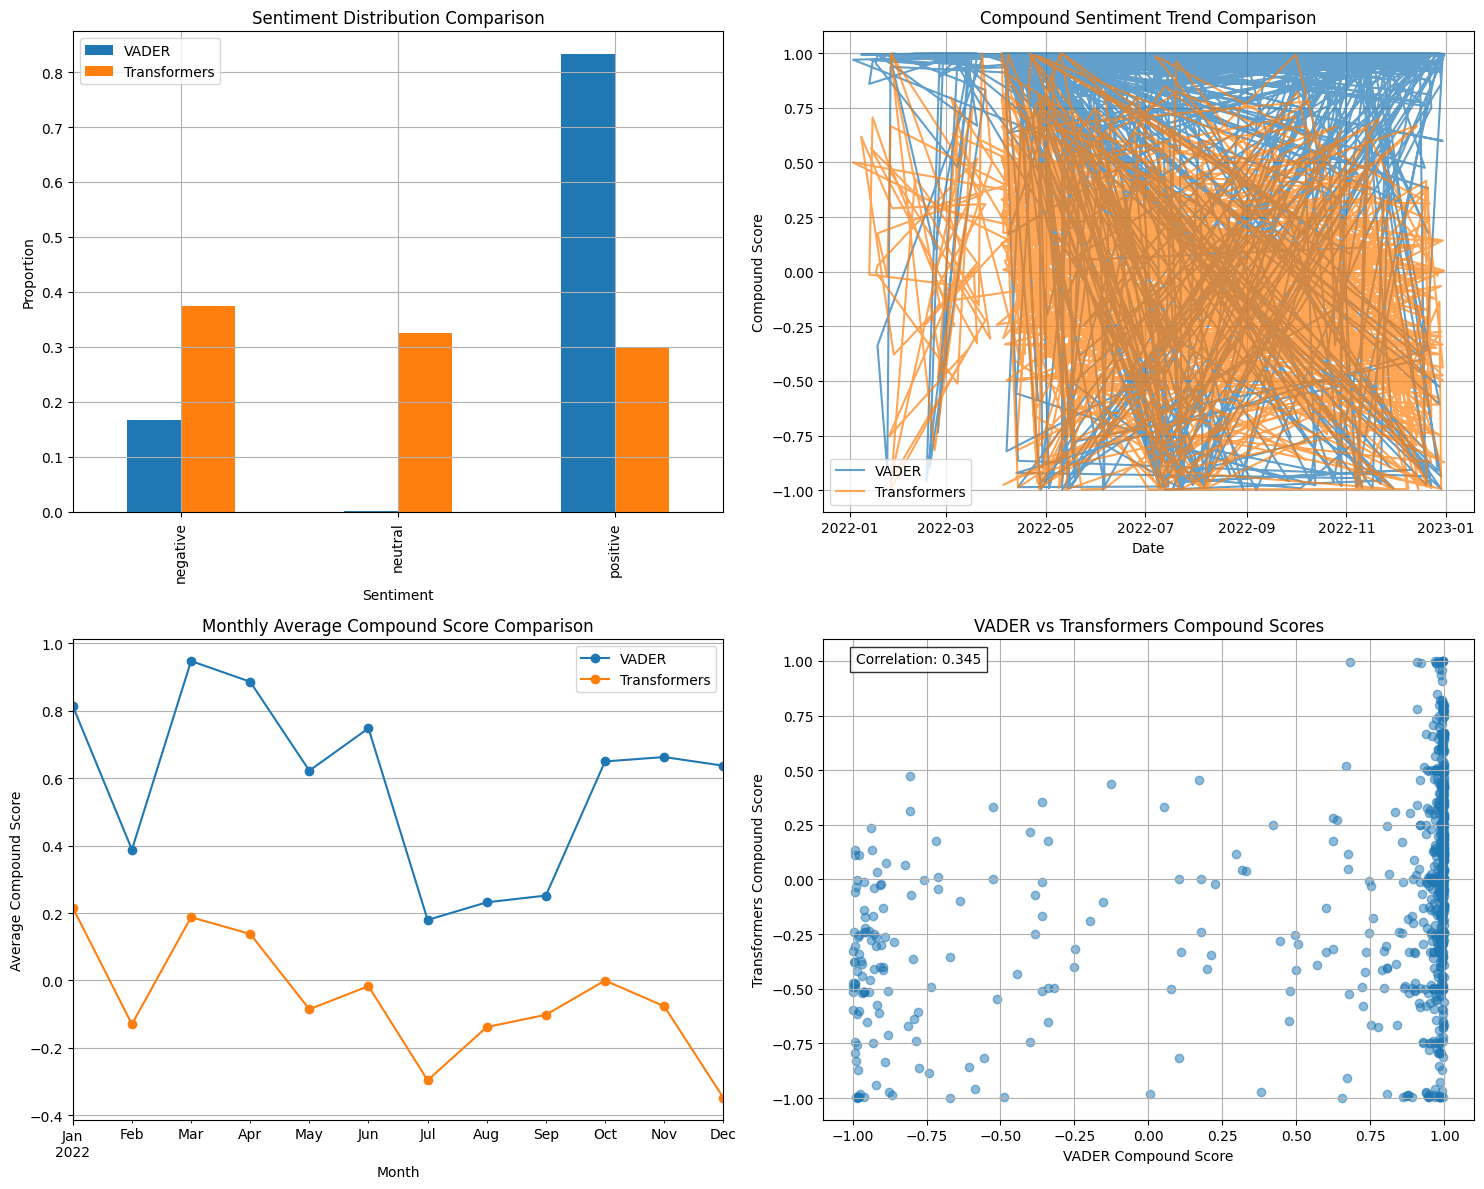


Sentiment Analysis Comparison Statistics:

1. Overall Statistics:
VADER Average Compound Score: 0.648
Transformers Average Compound Score: -0.057
VADER Standard Deviation: 0.673
Transformers Standard Deviation: 0.473

2. Sentiment Distribution:

VADER Distribution:
sentiment
positive    0.832
negative    0.166
neutral     0.001
Name: proportion, dtype: float64

Transformers Distribution:
sentiment
negative    0.374
neutral     0.326
positive    0.300
Name: proportion, dtype: float64

3. Agreement Statistics:
Proportion of articles with matching sentiment labels: 0.395

4. Confusion Matrix (VADER vs Transformers):
sentiment  negative  neutral  positive
sentiment                             
negative      0.109    0.045     0.013
neutral       0.001    0.000     0.000
positive      0.264    0.281     0.287


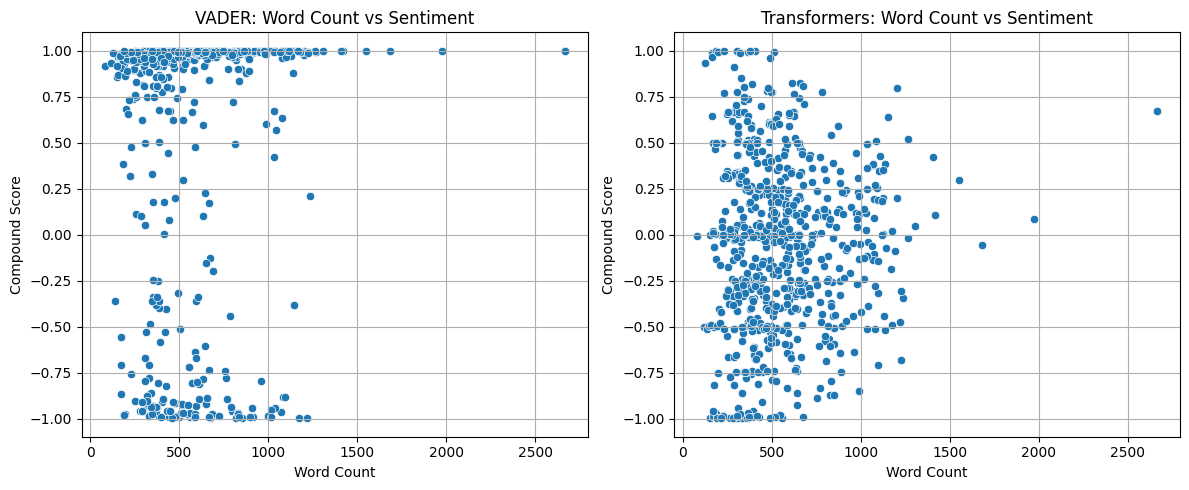


Word Count Correlation:
VADER: 0.006
Transformers: 0.069


In [10]:
def compare_sentiment_analyses(vader_df, transformers_df):
    """Compare sentiment analysis results between VADER and Transformers"""
    
    # Create subplots for comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Compare sentiment distributions
    vader_dist = vader_df['sentiment'].value_counts(normalize=True)
    transformers_dist = transformers_df['sentiment'].value_counts(normalize=True)
    
    # Combine distributions for comparison
    comparison_dist = pd.DataFrame({
        'VADER': vader_dist,
        'Transformers': transformers_dist
    }).fillna(0)
    
    comparison_dist.plot(kind='bar', ax=axes[0, 0])
    axes[0, 0].set_title('Sentiment Distribution Comparison')
    axes[0, 0].set_xlabel('Sentiment')
    axes[0, 0].set_ylabel('Proportion')
    axes[0, 0].grid(True)
    
    # 2. Compare compound scores over time
    vader_trend = vader_df.set_index('date')['compound']
    transformers_trend = transformers_df.set_index('date')['compound']
    
    axes[0, 1].plot(vader_trend.index, vader_trend, label='VADER', alpha=0.7)
    axes[0, 1].plot(transformers_trend.index, transformers_trend, label='Transformers', alpha=0.7)
    axes[0, 1].set_title('Compound Sentiment Trend Comparison')
    axes[0, 1].set_xlabel('Date')
    axes[0, 1].set_ylabel('Compound Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True)
    
    # 3. Compare monthly averages
    vader_monthly = vader_df.groupby(vader_df['date'].dt.to_period('M'))['compound'].mean()
    transformers_monthly = transformers_df.groupby(transformers_df['date'].dt.to_period('M'))['compound'].mean()
    
    monthly_comparison = pd.DataFrame({
        'VADER': vader_monthly,
        'Transformers': transformers_monthly
    })
    
    monthly_comparison.plot(kind='line', marker='o', ax=axes[1, 0])
    axes[1, 0].set_title('Monthly Average Compound Score Comparison')
    axes[1, 0].set_xlabel('Month')
    axes[1, 0].set_ylabel('Average Compound Score')
    axes[1, 0].grid(True)
    
    # 4. Scatter plot of VADER vs Transformers scores
    axes[1, 1].scatter(vader_df['compound'], transformers_df['compound'], alpha=0.5)
    axes[1, 1].set_title('VADER vs Transformers Compound Scores')
    axes[1, 1].set_xlabel('VADER Compound Score')
    axes[1, 1].set_ylabel('Transformers Compound Score')
    axes[1, 1].grid(True)
    
    # Add correlation line
    correlation = vader_df['compound'].corr(transformers_df['compound'])
    axes[1, 1].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
                   transform=axes[1, 1].transAxes, bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison statistics
    print("\nSentiment Analysis Comparison Statistics:")
    print("=" * 50)
    
    print("\n1. Overall Statistics:")
    print(f"VADER Average Compound Score: {vader_df['compound'].mean():.3f}")
    print(f"Transformers Average Compound Score: {transformers_df['compound'].mean():.3f}")
    print(f"VADER Standard Deviation: {vader_df['compound'].std():.3f}")
    print(f"Transformers Standard Deviation: {transformers_df['compound'].std():.3f}")
    
    print("\n2. Sentiment Distribution:")
    print("\nVADER Distribution:")
    print(vader_df['sentiment'].value_counts(normalize=True).round(3))
    print("\nTransformers Distribution:")
    print(transformers_df['sentiment'].value_counts(normalize=True).round(3))
    
    print("\n3. Agreement Statistics:")
    agreement = (vader_df['sentiment'] == transformers_df['sentiment']).mean()
    print(f"Proportion of articles with matching sentiment labels: {agreement:.3f}")
    
    # Calculate confusion matrix
    confusion = pd.crosstab(vader_df['sentiment'], transformers_df['sentiment'], 
                           normalize='all').round(3)
    print("\n4. Confusion Matrix (VADER vs Transformers):")
    print(confusion)
    
    return {
        'correlation': correlation,
        'agreement': agreement,
        'confusion_matrix': confusion
    }

# Compare the analyses
comparison_results = compare_sentiment_analyses(news_df_sentiment, news_df_transformers)

# Additional analysis: Compare sentiment-word count relationships
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=news_df_sentiment, x='word_count', y='compound')
plt.title('VADER: Word Count vs Sentiment')
plt.xlabel('Word Count')
plt.ylabel('Compound Score')
plt.grid(True)

plt.subplot(1, 2, 2)
sns.scatterplot(data=news_df_transformers, x='word_count', y='compound')
plt.title('Transformers: Word Count vs Sentiment')
plt.xlabel('Word Count')
plt.ylabel('Compound Score')
plt.grid(True)

plt.tight_layout()
plt.show()

# Print correlation coefficients
vader_corr = news_df_sentiment['word_count'].corr(news_df_sentiment['compound'])
transformers_corr = news_df_transformers['word_count'].corr(news_df_transformers['compound'])
print(f"\nWord Count Correlation:")
print(f"VADER: {vader_corr:.3f}")
print(f"Transformers: {transformers_corr:.3f}")

### Comparing against sales data and Forward looking moving averages

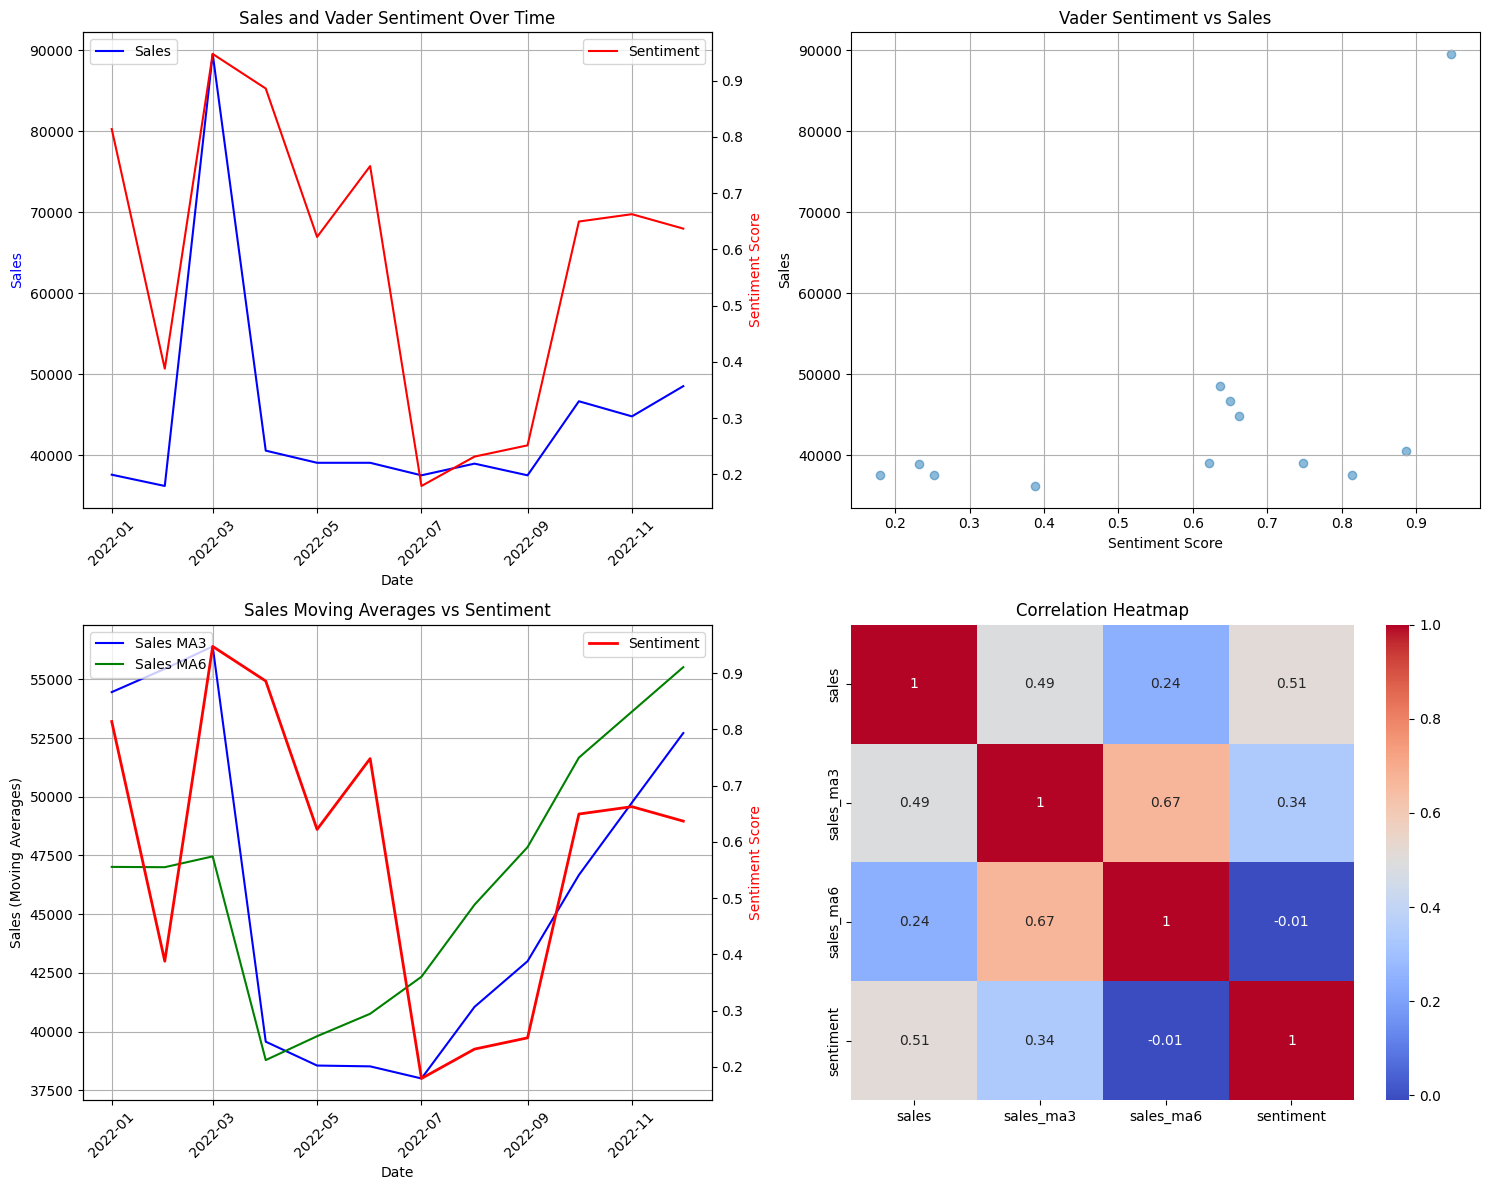


Vader Sentiment Analysis Statistics:
Correlation with sales: 0.511
Correlation with sales MA3: 0.339
Correlation with sales MA6: -0.010


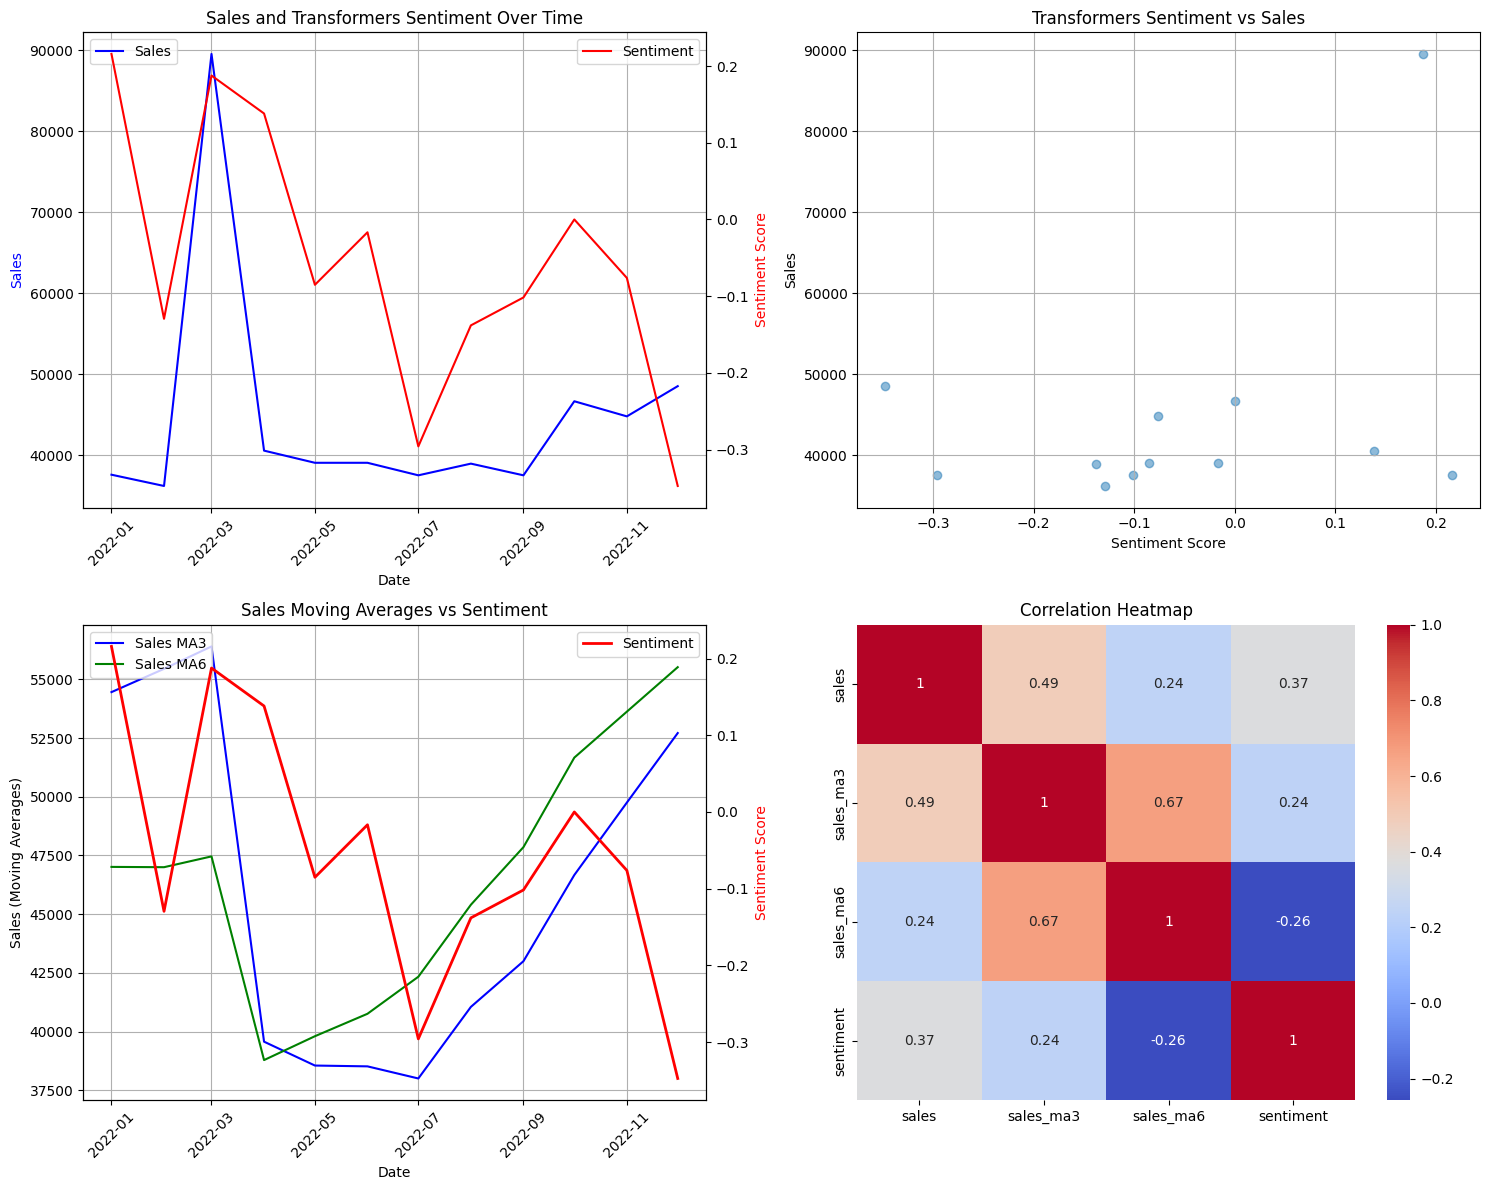


Transformers Sentiment Analysis Statistics:
Correlation with sales: 0.366
Correlation with sales MA3: 0.236
Correlation with sales MA6: -0.257


In [11]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_latest_sentiment_results(method='vader', results_dir='results'):
    pattern = f"{results_dir}/{method}_sentiment_analysis_*.csv"
    files = glob.glob(pattern)
    if not files:
        raise FileNotFoundError(f"No sentiment analysis files found for method '{method}' in {results_dir}")
    latest_file = max(files, key=os.path.getctime)
    df = pd.read_csv(latest_file)
    df['date'] = pd.to_datetime(df['date'])
    # Standardize column names
    df = df.rename(columns={
        'pos': 'positive', 'neg': 'negative', 'neu': 'neutral'
    })
    return df

# Usage:
news_df_sentiment = load_latest_sentiment_results('vader')
news_df_transformers = load_latest_sentiment_results('transformers')

def compare_sentiment_sales(sentiment_df, sales_df, method='vader'):
    # Ensure date columns are datetime and sorted
    sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
    sales_df['date'] = pd.to_datetime(sales_df['date'])
    sales_df = sales_df.sort_values('date')

    # Compute forward-looking moving averages on the full sales data
    sales_df['sales_ma3'] = sales_df['sales'].rolling(window=3, min_periods=1).mean().shift(-2)
    sales_df['sales_ma6'] = sales_df['sales'].rolling(window=6, min_periods=1).mean().shift(-5)

    # Monthly aggregation of sentiment
    sentiment_monthly = sentiment_df.groupby(sentiment_df['date'].dt.to_period('M')).agg({
        'compound': 'mean'
    }).reset_index()
    sentiment_monthly['date'] = sentiment_monthly['date'].dt.to_timestamp()

    # Merge on date for alignment (inner join to keep only overlapping months)
    merged = pd.merge(
        sales_df[['date', 'sales', 'sales_ma3', 'sales_ma6']],
        sentiment_monthly[['date', 'compound']],
        on='date',
        how='inner'
    )
    merged.rename(columns={'compound': 'sentiment'}, inplace=True)

    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    # 1. Sales and Sentiment Over Time
    ax1 = axes[0, 0]
    ax2 = ax1.twinx()
    ax1.plot(merged['date'], merged['sales'], 'b-', label='Sales')
    ax2.plot(merged['date'], merged['sentiment'], 'r-', label='Sentiment')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Sales', color='b')
    ax2.set_ylabel('Sentiment Score', color='r')
    ax1.set_title(f'Sales and {method.title()} Sentiment Over Time')
    ax1.grid(True)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')

    # 2. Sentiment vs Sales Scatter
    axes[0, 1].scatter(merged['sentiment'], merged['sales'], alpha=0.5)
    axes[0, 1].set_title(f'{method.title()} Sentiment vs Sales')
    axes[0, 1].set_xlabel('Sentiment Score')
    axes[0, 1].set_ylabel('Sales')
    axes[0, 1].grid(True)

    # 3. Sales Moving Averages vs Sentiment (dual y-axis)
    ax3 = axes[1, 0]
    ax4 = ax3.twinx()
    ax3.plot(merged['date'], merged['sales_ma3'], 'b-', label='Sales MA3')
    ax3.plot(merged['date'], merged['sales_ma6'], 'g-', label='Sales MA6')
    ax4.plot(merged['date'], merged['sentiment'], 'r-', label='Sentiment', linewidth=2)
    ax3.set_title('Sales Moving Averages vs Sentiment')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Sales (Moving Averages)')
    ax4.set_ylabel('Sentiment Score', color='r')
    ax3.legend(loc='upper left')
    ax4.legend(loc='upper right')
    ax3.grid(True)
    ax3.tick_params(axis='x', rotation=45)

    # 4. Correlation Heatmap
    correlation_matrix = merged[['sales', 'sales_ma3', 'sales_ma6', 'sentiment']].corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', ax=axes[1, 1])
    axes[1, 1].set_title('Correlation Heatmap')

    plt.tight_layout()
    plt.show()

    print(f"\n{method.title()} Sentiment Analysis Statistics:")
    print("=" * 50)
    print(f"Correlation with sales: {merged['sentiment'].corr(merged['sales']):.3f}")
    print(f"Correlation with sales MA3: {merged['sentiment'].corr(merged['sales_ma3']):.3f}")
    print(f"Correlation with sales MA6: {merged['sentiment'].corr(merged['sales_ma6']):.3f}")

    return merged

# Usage:
vader_analysis = compare_sentiment_sales(news_df_sentiment, sales_df, method='vader')
transformers_analysis = compare_sentiment_sales(news_df_transformers, sales_df, method='transformers')